# Bank Marketing Classification

## Reference workflow

This notebook predicts whether a customer subscribes to a term deposit. It profiles and cleans the data, encodes categorical predictors, uses a stratified train/test split, and compares the shared classifiers. Run cells from top to bottom; result files are written to `../Results/`.

In [1]:
# Import the data, plotting, and numerical tools used throughout the analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# The source file is semicolon-delimited, so specify its delimiter explicitly.
df = pd.read_csv("../Data/bank_marketing.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>,
        <Axes: title={'center': 'emp.var.rate'}>],
       [<Axes: title={'center': 'cons.price.idx'}>,
        <Axes: title={'center': 'cons.conf.idx'}>,
        <Axes: title={'center': 'euribor3m'}>],
       [<Axes: title={'center': 'nr.employed'}>, <Axes: >, <Axes: >]],
      dtype=object)

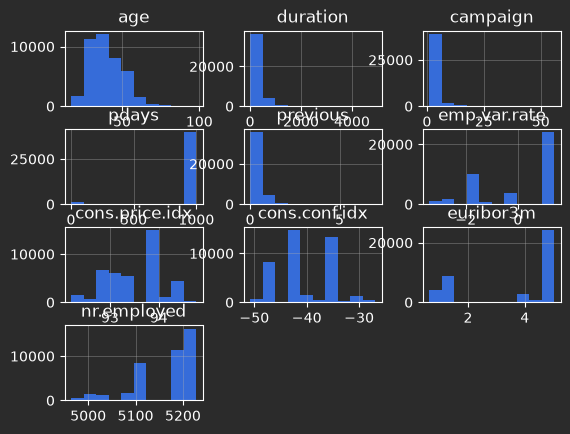

In [5]:
df.hist()

In [6]:
missing_value_counts = df.isnull().sum()
missing_value_counts

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
print(df.duplicated().sum())

12


In [8]:
# Remove duplicated observations so they do not receive extra weight during training.
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [9]:
df.shape

(41176, 21)

In [10]:
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1730
default           8596
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

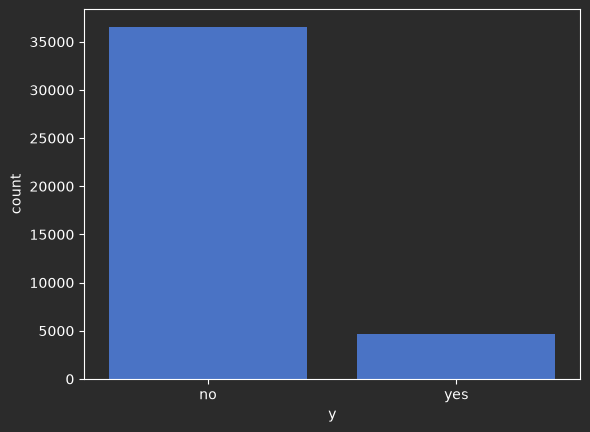

In [11]:
sns.countplot(x="y", data=df)
plt.show()

In [12]:
df.select_dtypes(include="str").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

In [13]:
# Keep the subscription outcome separate from the predictor variables.
X = df.drop('y', axis = 1)
Y = df['y']

In [14]:
# One-hot encode categorical columns for estimators that require numeric inputs.

X = pd.get_dummies(X, drop_first = True, dtype= int)

In [15]:
# Encode the binary target as 0/1 for consistent model handling.

Y = df['y'].map({'no': 0, 'yes': 1})

In [16]:
from utils.preprocessing import split_data, scale_data

# Split stratifies the target; scaling is fit only on the training set.
X_train, X_test, Y_train, Y_test = split_data(X, Y)

X_train_scaled, X_test_scaled = scale_data(
    X_train,
    X_test
)

Saving confusion matrix to: ../Results/confusion_matrices\Bank_Marketing_logistic_regression.png


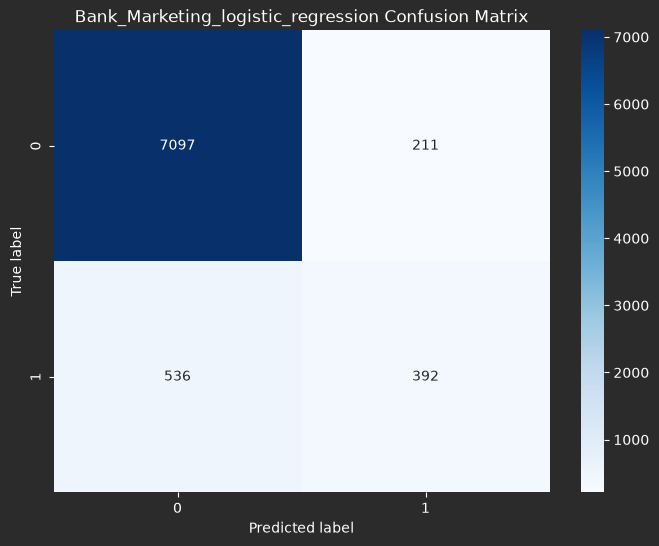


Classification Report - logistic_regression
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.65      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236

Saving JSON to: ../Results/Bank_Marketing_logistic_regression_20260814_174611.json

Model: logistic_regression
{'accuracy': 0.9093006313744536, 'precision': 0.8982635874066408, 'recall': 0.9093006313744536, 'f1': 0.9006602770866851, 'confusion_matrix': [[7097, 211], [536, 392]], 'classification_report': {'0': {'precision': 0.9297785929516573, 'recall': 0.9711275314723591, 'f1-score': 0.9500033464962184, 'support': 7308.0}, '1': {'precision': 0.6500829187396352, 'recall': 0.4224137931034483, 'f1-score': 0.51208360548661, 'support': 928.0}, 'accuracy': 0.9093006313744536, 'macro avg': {'precision': 0.7899307558456463, 'rec

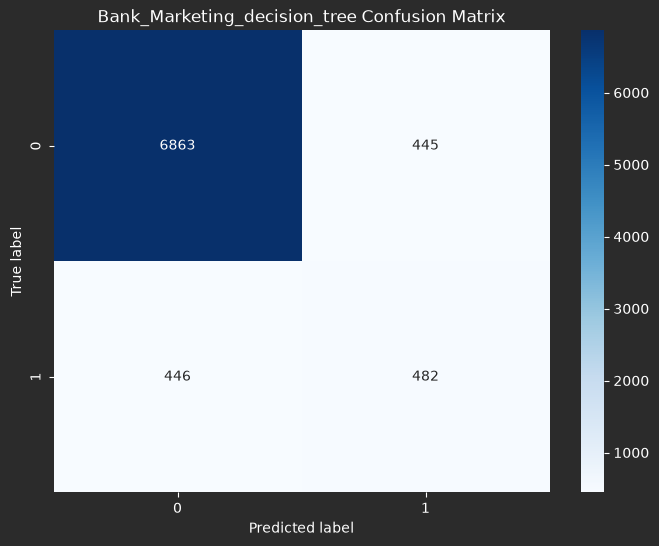


Classification Report - decision_tree
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7308
           1       0.52      0.52      0.52       928

    accuracy                           0.89      8236
   macro avg       0.73      0.73      0.73      8236
weighted avg       0.89      0.89      0.89      8236

Saving JSON to: ../Results/Bank_Marketing_decision_tree_20260814_174611.json

Model: decision_tree
{'accuracy': 0.8918164157357941, 'precision': 0.8917655387942587, 'recall': 0.8918164157357941, 'f1': 0.8917909563483774, 'confusion_matrix': [[6863, 445], [446, 482]], 'classification_report': {'0': {'precision': 0.9389793405390614, 'recall': 0.9391078270388615, 'f1-score': 0.9390435793938565, 'support': 7308.0}, '1': {'precision': 0.5199568500539374, 'recall': 0.5193965517241379, 'f1-score': 0.5196765498652292, 'support': 928.0}, 'accuracy': 0.8918164157357941, 'macro avg': {'precision': 0.7294680952964994, 'recall': 0.72925218

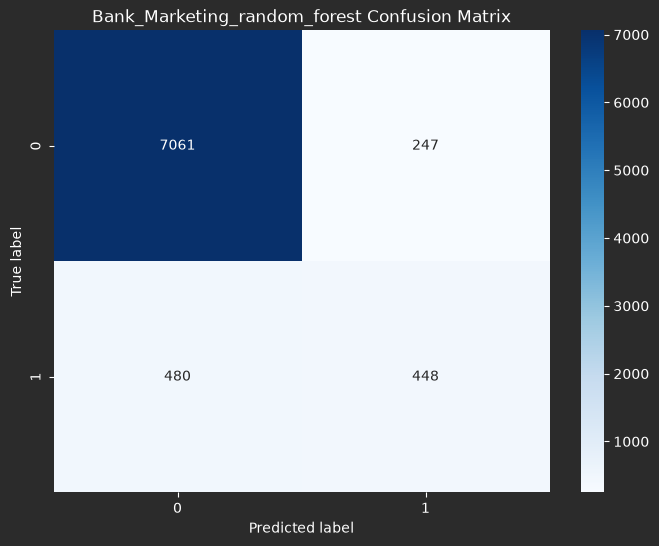


Classification Report - random_forest
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7308
           1       0.64      0.48      0.55       928

    accuracy                           0.91      8236
   macro avg       0.79      0.72      0.75      8236
weighted avg       0.90      0.91      0.91      8236

Saving JSON to: ../Results/Bank_Marketing_random_forest_20260814_174614.json

Model: random_forest
{'accuracy': 0.9117289946576008, 'precision': 0.9034754407523063, 'recall': 0.9117289946576008, 'f1': 0.9060853873184284, 'confusion_matrix': [[7061, 247], [480, 448]], 'classification_report': {'0': {'precision': 0.9363479644609468, 'recall': 0.9662014230979749, 'f1-score': 0.9510404741060005, 'support': 7308.0}, '1': {'precision': 0.6446043165467625, 'recall': 0.4827586206896552, 'f1-score': 0.5520640788662969, 'support': 928.0}, 'accuracy': 0.9117289946576008, 'macro avg': {'precision': 0.7904761405038547, 'recall': 0.72448002

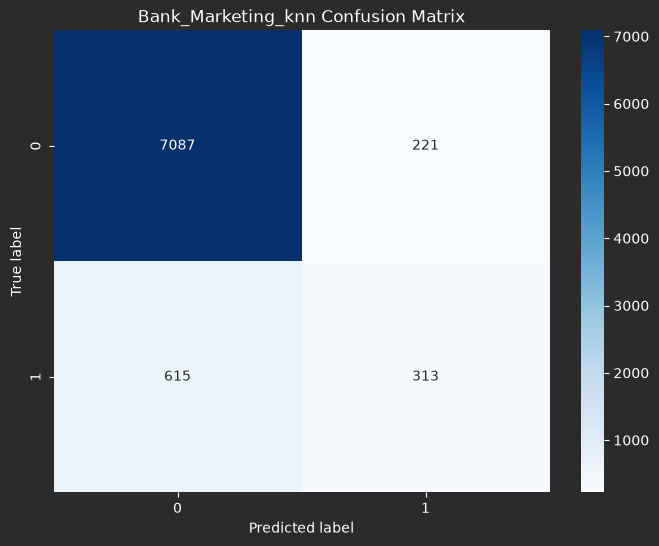


Classification Report - knn
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7308
           1       0.59      0.34      0.43       928

    accuracy                           0.90      8236
   macro avg       0.75      0.65      0.69      8236
weighted avg       0.88      0.90      0.89      8236

Saving JSON to: ../Results/Bank_Marketing_knn_20260814_174618.json

Model: knn
{'accuracy': 0.8984944147644488, 'precision': 0.8825158735399842, 'recall': 0.8984944147644488, 'f1': 0.8861490681260502, 'confusion_matrix': [[7087, 221], [615, 313]], 'classification_report': {'0': {'precision': 0.9201506102311088, 'recall': 0.9697591680350302, 'f1-score': 0.9443037974683545, 'support': 7308.0}, '1': {'precision': 0.5861423220973783, 'recall': 0.33728448275862066, 'f1-score': 0.42818057455540354, 'support': 928.0}, 'accuracy': 0.8984944147644488, 'macro avg': {'precision': 0.7531464661642435, 'recall': 0.6535218253968254, 'f1-score': 0.6862

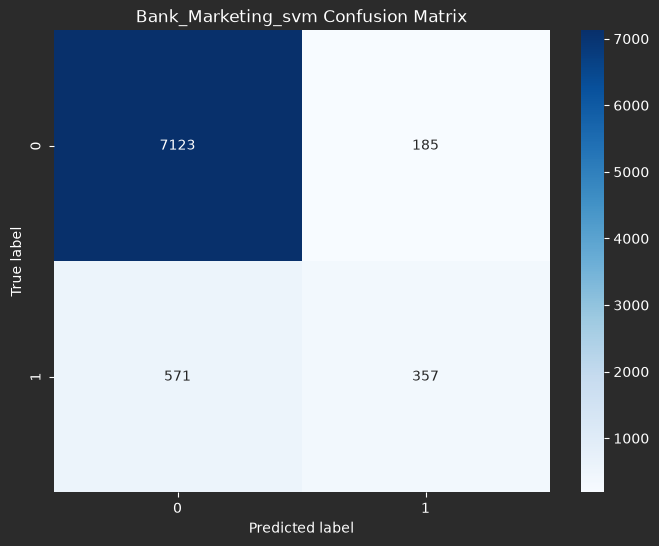


Classification Report - svm
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.66      0.38      0.49       928

    accuracy                           0.91      8236
   macro avg       0.79      0.68      0.72      8236
weighted avg       0.90      0.91      0.90      8236

Saving JSON to: ../Results/Bank_Marketing_svm_20260814_174638.json

Model: svm
{'accuracy': 0.9082078678970374, 'precision': 0.8956888914821775, 'recall': 0.9082078678970374, 'f1': 0.8973371491447015, 'confusion_matrix': [[7123, 185], [571, 357]], 'classification_report': {'0': {'precision': 0.9257863270080582, 'recall': 0.9746852764094144, 'f1-score': 0.9496067191041194, 'support': 7308.0}, '1': {'precision': 0.6586715867158671, 'recall': 0.38469827586206895, 'f1-score': 0.4857142857142857, 'support': 928.0}, 'accuracy': 0.9082078678970374, 'macro avg': {'precision': 0.7922289568619627, 'recall': 0.6796917761357417, 'f1-score': 0.71766

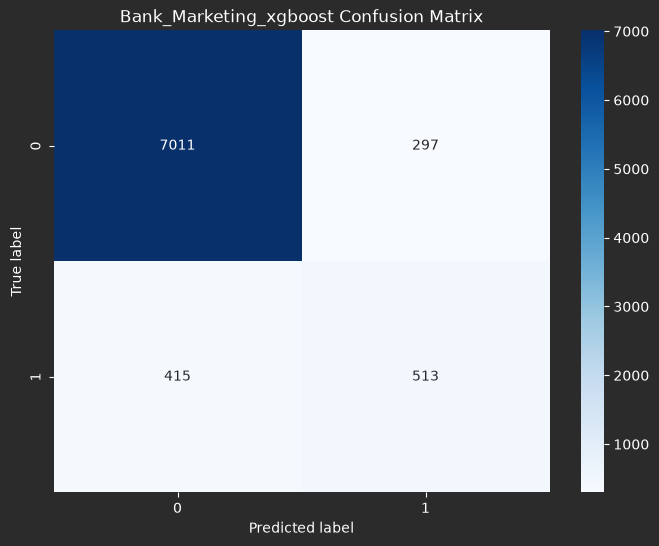


Classification Report - xgboost
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.63      0.55      0.59       928

    accuracy                           0.91      8236
   macro avg       0.79      0.76      0.77      8236
weighted avg       0.91      0.91      0.91      8236

Saving JSON to: ../Results/Bank_Marketing_xgboost_20260814_174639.json

Model: xgboost
{'accuracy': 0.9135502671199611, 'precision': 0.9090975875903595, 'recall': 0.9135502671199611, 'f1': 0.9109617268101968, 'confusion_matrix': [[7011, 297], [415, 513]], 'classification_report': {'0': {'precision': 0.9441152706706167, 'recall': 0.9593596059113301, 'f1-score': 0.95167639473327, 'support': 7308.0}, '1': {'precision': 0.6333333333333333, 'recall': 0.552801724137931, 'f1-score': 0.5903337169159953, 'support': 928.0}, 'accuracy': 0.9135502671199611, 'macro avg': {'precision': 0.788724302001975, 'recall': 0.7560806650246306, 'f1-score': 

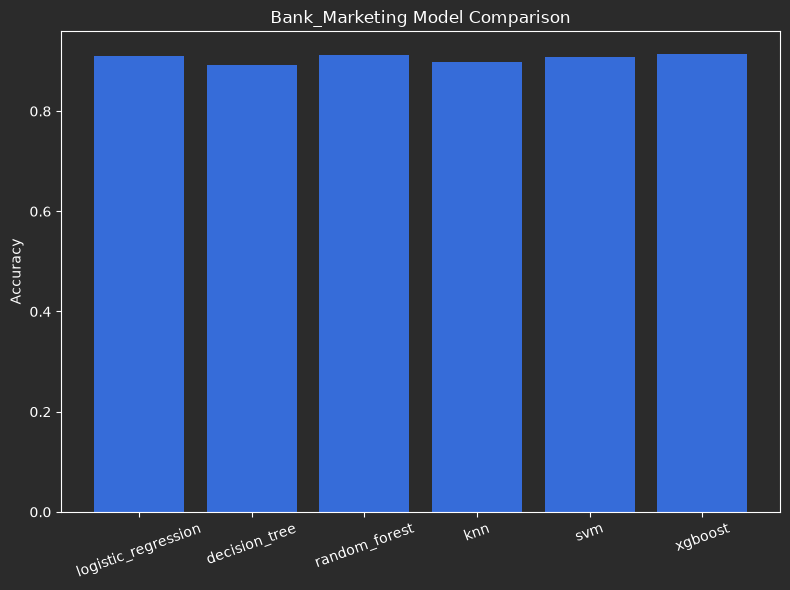

In [17]:
from Models.pipeline import run_pipeline
from utils.logger import save_accuracy_table
from utils.visualization import plot_accuracy_graph

dataset_name = "Bank_Marketing"

models = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "knn",
    "svm",
    "xgboost"
]

all_results = []

# Evaluate every model on the identical holdout set for a fair comparison.
for model in models:

    results = run_pipeline(
        X_train,
        X_test,
        X_train_scaled,
        X_test_scaled,
        Y_train,
        Y_test,
        model,
        "Bank_Marketing"
    )

    all_results.append({
        "Model": model,
        "Accuracy": results["accuracy"],
        "Precision": results["precision"],
        "Recall": results["recall"],
        "F1": results["f1"]
    })

    print(f"\n{'='*50}")
    print(f"Model: {model}")
    print(results)

save_accuracy_table(dataset_name, all_results)
plot_accuracy_graph(dataset_name, all_results)

In [18]:
# Find best model based on accuracy
best_model = max(
    all_results,
    key=lambda x: x["Accuracy"]
)

print("\n" + "=" * 60)
print("BEST PERFORMING MODEL")
print("=" * 60)

print(f"Dataset   : {dataset_name}")
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1 Score  : {best_model['F1']:.4f}")


BEST PERFORMING MODEL
Dataset   : Bank_Marketing
Model     : xgboost
Accuracy  : 0.9136
Precision : 0.9091
Recall    : 0.9136
F1 Score  : 0.9110
